<a href="https://colab.research.google.com/github/gmauricio-toledo/math-ML/blob/main/Notebooks/06-ML-Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>El workflow del Aprendizaje Automático</h1>

Hasta ahora hemos tratado la regresión lineal como un problema puramente algebraico: dados datos $\{x_i\}$ y etiquetas $\{y_i\}$, derivamos una fórmula para los coeficientes $a,b$ del modelo $f_{a,b}$ que minimizan el error cuadrático.

Pero esa derivación esconde una pregunta: ¿cómo sabemos que lo que encontramos es una buena lógica y no un accidente de los datos que nos tocó ver?

En esta notebook formalizamos el protocolo estándar del aprendizaje supervisado. La idea es: separamos los datos en dos conjuntos disjuntos, entrenamos el modelo usando sólo uno de ellos, y evaluamos su desempeño en el otro, que el modelo nunca ha visto.

Esta división nos permite distinguir entre ajustar (memorizar los datos de entrenamiento) y aprender (capturar una regularidad que se manifiesta también en datos nuevos).

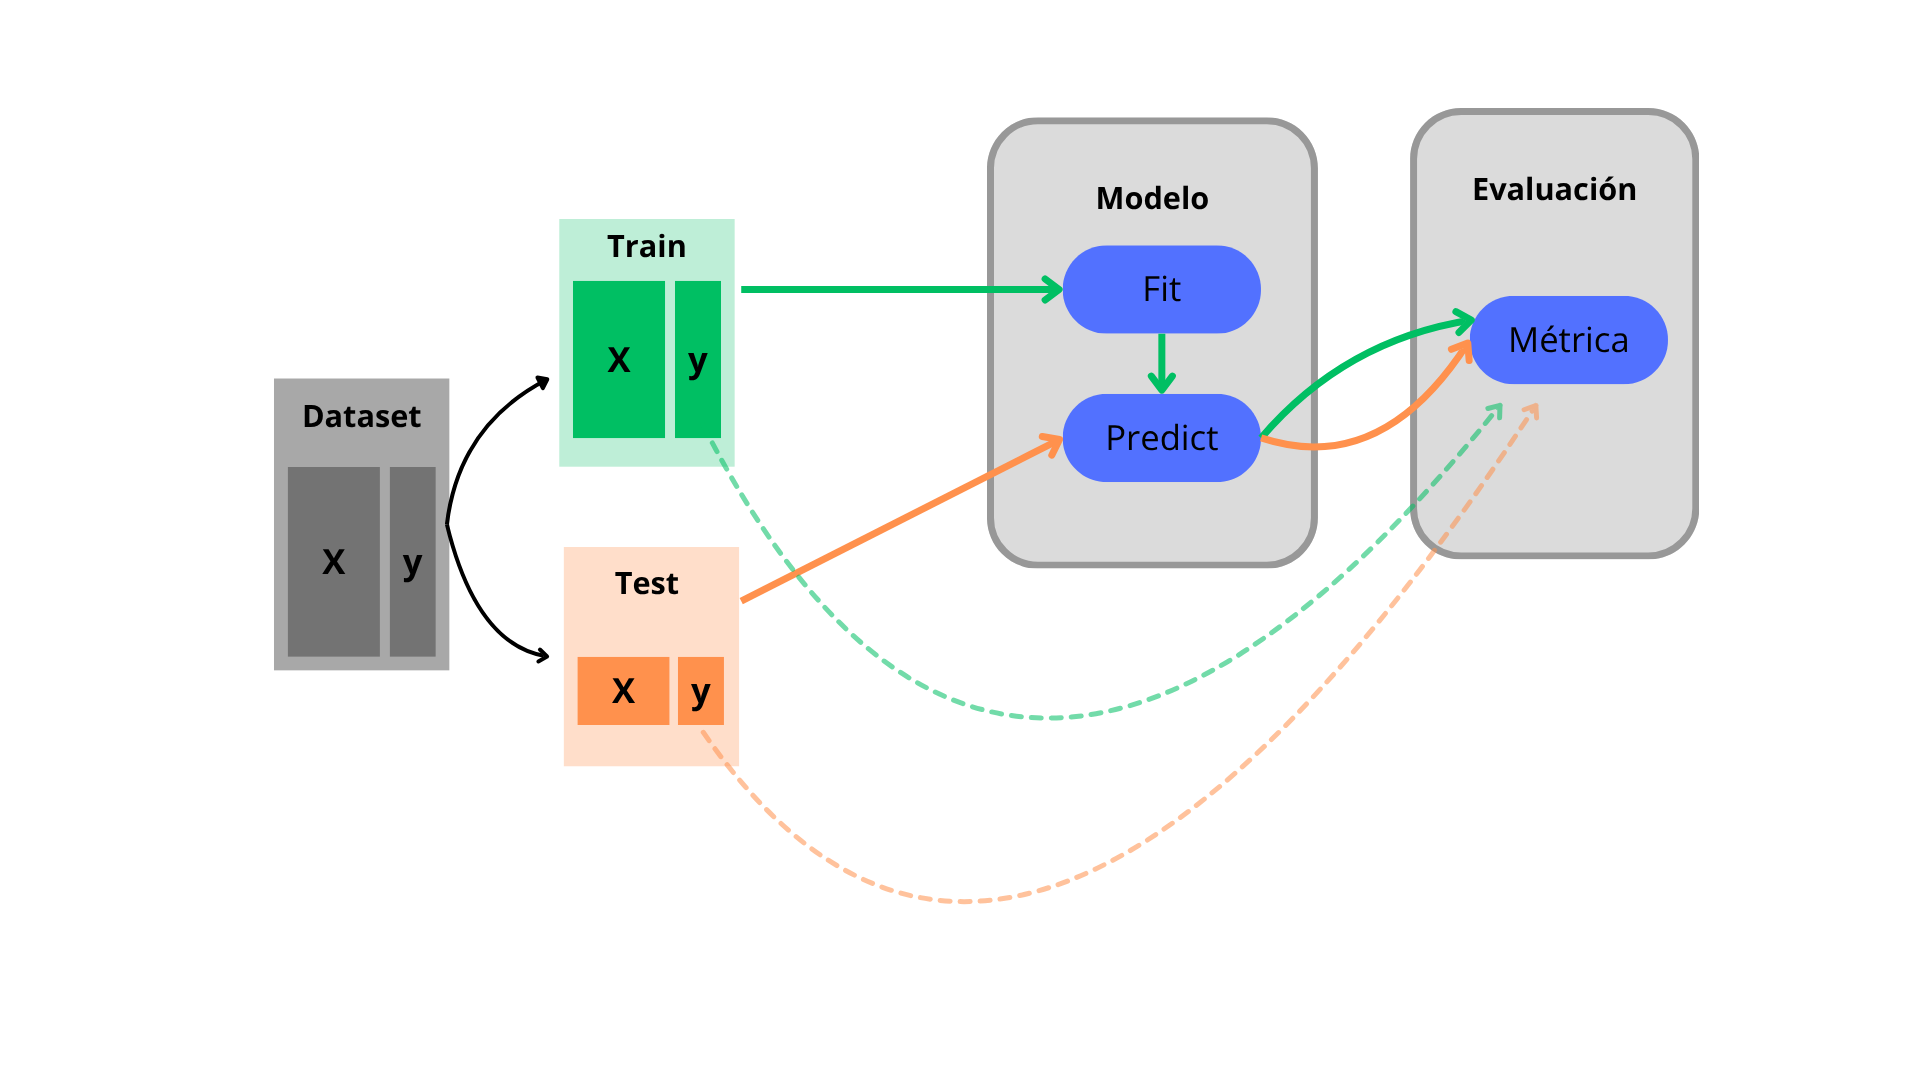

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

#------------- Conjunto de datos -------------
num_points = 80
np.random.seed(17)
xs = np.random.uniform(-10, 10, num_points)
ys = 0.5*xs - 2 + np.random.normal(0, 1, num_points)

#------------- Separación de datos -------------
x_train, x_test, y_train, y_test = train_test_split(xs, ys, test_size=0.25)

#------------- Entrenamiento y predicción del modelo -------------
model_1 = LinearRegression()
model_1.fit(x_train.reshape(-1, 1), y_train)
train_error_1 = mean_squared_error(y_train, model_1.predict(x_train.reshape(-1, 1)))
test_error_1 = mean_squared_error(y_test, model_1.predict(x_test.reshape(-1, 1)))

model_2 = DecisionTreeRegressor(max_depth=6)
model_2.fit(x_train.reshape(-1, 1), y_train)
train_error_2 = mean_squared_error(y_train, model_2.predict(x_train.reshape(-1, 1)))
test_error_2 = mean_squared_error(y_test, model_2.predict(x_test.reshape(-1, 1)))

#------------- Gráficas -------------
x_axis = np.linspace(-10, 10, 100) # Discretización del eje X
y_axis_1 = model_1.predict(x_axis.reshape(-1, 1)) # El modelo 1 evaluado en la discretización
y_axis_2 = model_2.predict(x_axis.reshape(-1, 1)) # El modelo 2 evaluado en la discretización

plt.figure(figsize=(10,15))
plt.subplot(3,2,1)
plt.scatter(xs, ys)
plt.title('Conjunto de datos')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,2)
plt.scatter(x_train, y_train,label='train',c='green')
plt.scatter(x_test, y_test,label='test',c='orange')
plt.legend(loc='best')
plt.title('Conjunto de entrenamiento y prueba')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,3)
plt.scatter(x_train, y_train,c='green')
plt.plot(x_axis, y_axis_1,c='darkgreen',linewidth=3)
plt.title(f'Error de entrenamiento: {train_error_1:.2f}')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,4)
plt.scatter(x_test, y_test,c='orange')
plt.plot(x_axis, y_axis_1,c='darkgreen',linewidth=3)
plt.title(f'Error de prueba: {test_error_1:.2f}')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,5)
plt.scatter(x_train, y_train,c='green')
plt.plot(x_axis, y_axis_2,c='darkgreen',linewidth=3)
plt.title(f'Error de entrenamiento: {train_error_2:.2f}')
plt.xticks([])
plt.yticks([])
plt.subplot(3,2,6)
plt.scatter(x_test, y_test,c='orange')
plt.plot(x_axis, y_axis_2,c='darkgreen',linewidth=3)
plt.title(f'Error de prueba: {test_error_2:.2f}')
plt.show()

🔵 Algunas cosas que notar:

* ¿Qué efecto tiene la proporción entrenamiento/prueba? ¿Qué pasa si usamos 50/50 en lugar de 75/25? ¿Y 90/10?
* ¿Por qué el error de prueba suele ser más grande?
* Tratamos `test` como si fueran "datos que aún no hemos visto". ¿Qué hipótesis estamos haciendo al tratar una partición aleatoria de los datos como si fuera el futuro? ¿Cuándo podría fallar esa hipótesis?
* Cambia `np.random.seed(17)` por otro valor y vuelve a correr. Los errores cambian. ¿Qué nos dice esto sobre el error de test como *estimador* del verdadero error de prueba? ¿Es una cantidad fija del modelo o una variable aleatoria?


En este experimento, generamos un conjunto de datos sintético con una relación lineal subyacente y repetimos 1000 veces el proceso de dividirlo en conjuntos de entrenamiento (75%) y prueba (25%), utilizando una semilla aleatoria diferente en cada iteración.

Para cada partición, entrenamos un modelo de regresión lineal y registramos su error cuadrático medio (MSE) en los datos de prueba.

Al visualizar estos resultados en un histograma, observamos una distribución de errores que muestra que el error de prueba no es un valor fijo o absoluto del modelo, sino una variable aleatoria cuyo valor depende de la muestra específica asignada a prueba.

La dispersión de esta distribución cuantifica la varianza del estimador, evidenciando la incertidumbre inherente al evaluar el rendimiento de generalización de un modelo basándose en una única partición aleatoria de los datos.

Este experimento es la base de una técnica llamada **Validación cruzada** (Cross Validation).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import ipywidgets as widgets
from IPython.display import display

# ------------- Dataset fijo -------------
num_points = 100
np.random.seed(17)
xs = np.random.uniform(-10, 10, num_points)
ys = 0.5*xs - 2 + np.random.normal(0, 1, num_points)

# ------------- Seeds -------------
max_seeds = 3000
seeds = np.arange(max_seeds)

# ------------- Función que se actualiza con el slider -------------
def experimento(n_seeds=100):
    test_errors = []

    for seed in seeds[:n_seeds]:
        x_train, x_test, y_train, y_test = train_test_split(
                                                xs, ys,
                                                test_size=0.25,
                                                random_state=int(seed)
                                                )
        model = LinearRegression()
        model.fit(x_train.reshape(-1, 1), y_train)
        pred = model.predict(x_test.reshape(-1, 1))
        test_errors.append(mean_squared_error(y_test, pred))

    test_errors = np.array(test_errors)
    media = np.mean(test_errors)
    std   = np.std(test_errors)

    # Gráfica
    plt.figure(figsize=(8, 4))
    plt.hist(test_errors, bins=30, range=(0, 3),
             color='orange', edgecolor='black')
    plt.axvline(media, color='red', linestyle='--', linewidth=2,
                label=f'Media: {media:.3f}')
    plt.title(f'Distribución del error de prueba con {n_seeds} particiones)\n'
              f'Desv. Est.: {std:.3f}')
    plt.xlabel('Error de prueba')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------- Slider -------------
slider = widgets.IntSlider(
    value=100,
    min=10,
    max=max_seeds,
    step=10,
    description='N particiones:',
    continuous_update=False,   # solo recalcula al soltar el slider
    layout=widgets.Layout(width='500px')
)

widgets.interact(experimento, n_seeds=slider)

<h3> 🟢 Nunca juzgar un modelo con los datos que usó para aprender.</h3>

🔵 El entrenamiento como proceso de optimización

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

def loss(a,b):
    n = xs.shape[0]
    fx = a*xs + b
    mse = np.sum((ys-fx)**2)/n
    return mse

a0, b0 = model_1.coef_, model_1.intercept_

# Define the domain for a and b
a_vals = np.linspace(-3, 3, 100)
b_vals = np.linspace(-3, 3, 100)
A, B = np.meshgrid(a_vals, b_vals)

# Calculate the loss for each (a, b) pair
Z = np.array([loss(a, b) for a, b in zip(A.ravel(), B.ravel())]).reshape(A.shape)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(A, B, Z, cmap='viridis', alpha=0.8)
ax.scatter(a0, b0, loss(a0, b0), color='red', marker='o', s=100)
# Add labels and title
ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_zlabel('Loss (MSE)')
ax.set_title('3D Plot of MSE Loss Function')
plt.tight_layout()
plt.show()

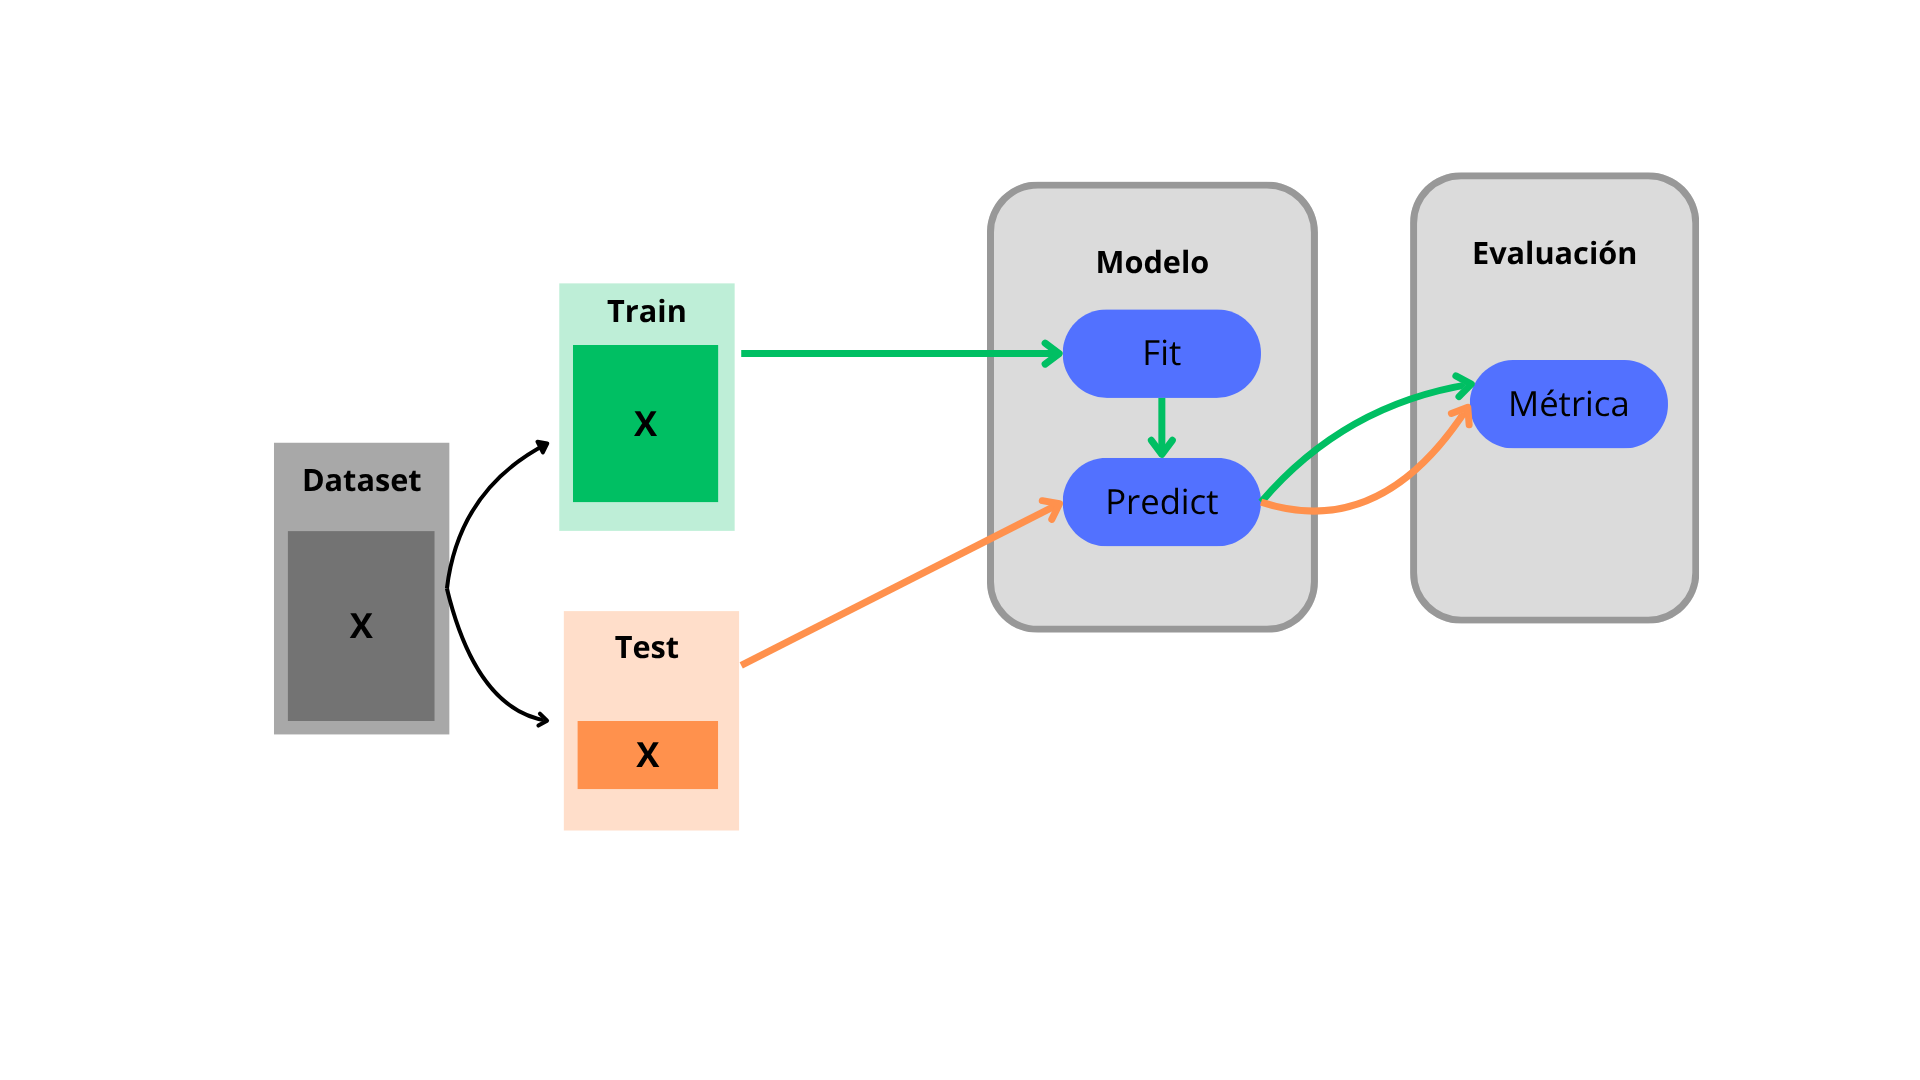

## 🔴 Tarea 2

1. Para un conjunto de datos $X=\{x_1,...,x_n\}⊂ \mathbb{R}$ con etiquetas $Y=\{y_1,...,y_n\}⊂ \mathbb{R}$, considera la familia de funciones reales

 $$\mathcal{F}=\{x\mapsto f_{a,b}(x)=ax+b \,|\, a,b\in\mathbb{R}\}$$
    y considera la función de perdida del **error cuadrático medio** (MSE)

$$\mathcal{L}(a,b)=\frac{1}{n}\sum_{i=1}^n (y_i - f_{a,b}(x_i))^2 $$

 encuentra el mínimo de esta función